# 04 - DPR (Dense Passage Retrieval) on MS MARCO

This notebook uses the DPR algorithm and branches it on the project's PostgreSQL database.

**Pipeline :**
1. Install the DPR dependencies 
2. Encode the entries from the database using the DPR model
3. Store the embeddings in the `dpr` table
4. Perform searches and display the results
5. Evaluate using qrels (MRR@10)

**Prerequisites :** execute `01_data_preparation.ipynb` (DB initialized and populated).

## 0) Setup — path and imports

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

env_path = project_root / ".env"
print(f"Project root : {project_root}")
print(f".env trouvé  : {env_path.exists()}")

Project root : C:\Users\lakaf\OneDrive\Bureau\25-26\S2\Big data\code_1203
.env trouvé  : True


## 1) Install DPR dependencies

To be execute just once.

In [ ]:
import subprocess

packages = ["sentence-transformers", "faiss-cpu"]
subprocess.run([sys.executable, "-m", "pip", "install"] + packages, check=True)

## 2) DB connection and verification

In [4]:
import warnings
import pandas as pd
from src.database.connection import get_connection

warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy.*", category=UserWarning)

conn = get_connection()

# check the number of available passes and queries
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM passages")
nb_passages = cursor.fetchone()[0]
cursor.execute("SELECT COUNT(*) FROM queries")
nb_queries = cursor.fetchone()[0]
cursor.execute("SELECT COUNT(*) FROM dpr")
nb_dpr = cursor.fetchone()[0]
cursor.close()

print(f"Passages en BDD    : {nb_passages:,}")
print(f"Queries en BDD     : {nb_queries:,}")
print(f"Embeddings DPR     : {nb_dpr:,}")

conn.close()

2026-03-13 10:50:07,389 - INFO - Database connection established successfully.


Passages en BDD    : 676,193
Queries en BDD     : 82,326
Embeddings DPR     : 0


## 3) Load DPR template 

In [5]:
from sentence_transformers import SentenceTransformer

# template for transforming raw text into vectors
print("Chargement du modèle msmarco-MiniLM-L-6-v3...")
model = SentenceTransformer("msmarco-MiniLM-L-6-v3")
print(f"Modèle chargé. Dimension des embeddings : {model.get_sentence_embedding_dimension()}")

c:\Users\lakaf\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-13 10:50:34,644 - INFO - Use pytorch device_name: cpu
2026-03-13 10:50:34,644 - INFO - Load pretrained SentenceTransformer: msmarco-MiniLM-L-6-v3


Chargement du modèle msmarco-MiniLM-L-6-v3...


2026-03-13 10:50:35,209 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/msmarco-MiniLM-L-6-v3/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-13 10:50:35,317 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/msmarco-MiniLM-L6-v3/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-13 10:50:35,317 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-03-13 10:50:35,336 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/msmarco-MiniLM-L6-v3/fea93b3df3924e5649a4e322c345f951239d2c13/modules.json "HTTP/1.1 200 OK"
2026-03-13 10:50:35,467 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/msmarco-MiniLM-L-6-v3/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-03-13 10:50:35,576 - INFO - HTTP Request: HEAD ht

Modèle chargé. Dimension des embeddings : 384


## 4) Encode the passages and store them in the `dpr` table

**Parameter `LIMIT_PASSAGES`** : Adjust according to your available RAM.
- `10_000` → fast, ~2-3 min, ~300 MB RAM
- `100_000` → full, ~20 min, ~3 GB RAM

If embeddings already exist, the cell skips them (`ON CONFLICT DO NOTHING`).

For a deep model of 768 dimensions : 

In [18]:
from src.database.connection import get_connection

conn = get_connection()
cursor = conn.cursor()

try:
    print("Réinitialisation de la table dpr à 768 dimensions...")
    # On vide la table pour éviter les erreurs de conversion
    cursor.execute("TRUNCATE TABLE dpr;") 
    # On repasse à 768
    cursor.execute("ALTER TABLE dpr ALTER COLUMN embedding TYPE vector(768);")
    conn.commit()
    print("Succès ! La base attend maintenant des vecteurs de taille 768.")
except Exception as e:
    conn.rollback()
    print(f"Erreur : {e}")
finally:
    cursor.close()
    conn.close()

2026-03-13 11:00:16,840 - INFO - Database connection established successfully.


Réinitialisation de la table dpr à 768 dimensions...
Succès ! La base attend maintenant des vecteurs de taille 768.


Indexing :

In [ ]:
import numpy as np
from psycopg2.extras import execute_values
from sentence_transformers import SentenceTransformer
from src.database.connection import get_connection

# Loading the model (768 dim)
print("Chargement du modèle msmarco-distilbert-base-v4 (768 dim)...")
model = SentenceTransformer("msmarco-distilbert-base-v4")
dimension = model.get_sentence_embedding_dimension()
print(f"Modèle chargé. Dimension : {dimension}")

# ── INSERTION PARAMETERS ────────────────────────────────────────────
LIMIT_PASSAGES = 10_000   # Number of passes to process
BATCH_SIZE     = 128      # simultaneous passages
# ──────────────────────────────────────────────────────────────────────

# Data Recovery
conn = get_connection()
cursor = conn.cursor()

print(f"Récupération de {LIMIT_PASSAGES} passages depuis la table 'passages'...")
cursor.execute(
    """
    SELECT p.id, p.text
    FROM passages p
    LEFT JOIN dpr d ON d.passage_id = p.id
    WHERE d.passage_id IS NULL
    ORDER BY p.id
    LIMIT %s
    """,
    (LIMIT_PASSAGES,)
)
rows = cursor.fetchall()
passage_ids = [r[0] for r in rows]
passage_texts = [r[1] for r in rows]

if len(passage_ids) == 0:
    print("Tous les passages sont déjà encodés ou la table source est vide.")
else:
    # Encoding
    print(f"Encodage de {len(passage_ids)} passages en cours (cela peut prendre quelques minutes)...")
    embeddings = model.encode(
        passage_texts,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    #Insertion into the dpr table
    print("Insertion des vecteurs dans la base de données...")
    data = [(int(pid), emb.tolist()) for pid, emb in zip(passage_ids, embeddings)]

    execute_values(
        cursor,
        """
        INSERT INTO dpr (passage_id, embedding)
        VALUES %s
        ON CONFLICT (passage_id) DO NOTHING
        """,
        data,
        template="(%s, %s::vector)",
        page_size=500
    )
    conn.commit()
    print(f"Terminé ! {len(data):,} embeddings de dimension {dimension} ont été insérés.")

cursor.close()
conn.close()

2026-03-13 11:00:18,979 - INFO - Use pytorch device_name: cpu
2026-03-13 11:00:18,985 - INFO - Load pretrained SentenceTransformer: msmarco-distilbert-base-v4


Chargement du modèle msmarco-distilbert-base-v4 (768 dim)...


2026-03-13 11:00:19,320 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/msmarco-distilbert-base-v4/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-13 11:00:19,342 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/msmarco-distilbert-base-v4/b2f66c95aba1481a880479165582020c2b9b64d7/modules.json "HTTP/1.1 200 OK"
2026-03-13 11:00:19,459 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/msmarco-distilbert-base-v4/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-03-13 11:00:19,480 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/msmarco-distilbert-base-v4/b2f66c95aba1481a880479165582020c2b9b64d7/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-03-13 11:00:19,595 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/msmarco-distilbert-base-v4/resolve/main/config_sent

Modèle chargé. Dimension : 768
Récupération de 10000 passages depuis la table 'passages'...
Encodage de 10000 passages en cours (cela peut prendre quelques minutes)...


Batches: 100%|██████████| 79/79 [20:38<00:00, 15.68s/it]


Insertion des vecteurs dans la base de données...
Terminé ! 10,000 embeddings de dimension 768 ont été insérés.


## 5) DPR search

Change `QUERY` to test any question.

In [22]:
import time
from src.database.connection import get_connection

# ── MODIFIABLE PARAMETER ──
QUERY = "Where is Paris?"   
TOP_K = 5
# ──────────────────────────

# Encode
query_embedding = model.encode([QUERY], convert_to_numpy=True)[0].tolist()

conn = get_connection()
cursor = conn.cursor()

t0 = time.time()
cursor.execute(
    """
    SELECT d.passage_id,
           p.text,
           1 - (d.embedding <=> %s::vector) AS score
    FROM dpr d
    JOIN passages p ON p.id = d.passage_id
    ORDER BY d.embedding <=> %s::vector
    LIMIT %s
    """,
    (query_embedding, query_embedding, TOP_K)
)
results = cursor.fetchall()
latency_ms = (time.time() - t0) * 1000

cursor.close()
conn.close()

print(f"Requête : '{QUERY}'")
print(f"Latence : {latency_ms:.1f} ms\n")
print(f"--- TOP {TOP_K} RÉSULTATS ---")
for i, (pid, text, score) in enumerate(results, 1):
    print(f"\n#{i} (passage_id={pid}, score={score:.4f})")
    print(text)

Batches: 100%|██████████| 1/1 [00:00<00:00, 30.62it/s]
2026-03-13 11:25:08,732 - INFO - Database connection established successfully.


Requête : 'Where is Paris?'
Latence : 26.7 ms

--- TOP 5 RÉSULTATS ---

#1 (passage_id=7281, score=0.1740)
Carbon: the essentials. Carbon is a Group 14 element and is distributed very widely in nature. It is found in abundance in the sun, stars, comets, and atmospheres of most planets. Carbon is present as carbon dioxide in the atmosphere and dissolved in all natural waters.

#2 (passage_id=42, score=0.1689)
Glucose. Glucose is a carbohydrate, and is the most important simple sugar in human metabolism. Glucose is called a simple sugar or a monosaccharide because it is one of the smallest units which has the characteristics of this class of carbohydrates. Glucose is also sometimes called dextrose. Corn syrup is primarily glucose.

#3 (passage_id=7280, score=0.1669)
Carbon is a Group 14 element and is distributed very widely in nature. It is found in abundance in the sun, stars, comets, and atmospheres of most planets. Carbon is present as carbon dioxide in the atmosphere and dissolved i

## 6) Log the search to the DB (table `search_logs` + `results`)

In [23]:
from psycopg2.extras import execute_values
from src.database.connection import get_connection

conn = get_connection()
cursor = conn.cursor()

cursor.execute(
    """
    INSERT INTO search_logs (timestamp, algorithm, query, latency_ms)
    VALUES (NOW(), 'DPR', %s, %s)
    RETURNING id
    """,
    (QUERY, latency_ms)
)
log_id = cursor.fetchone()[0]

execute_values(
    cursor,
    "INSERT INTO results (search_log_id, algorithm, passage_id, rank, score) VALUES %s",
    [(log_id, 'DPR', r[0], i + 1, float(r[2])) for i, r in enumerate(results)]
)
conn.commit()
cursor.close()
conn.close()

print(f"Recherche loggée (search_log_id={log_id})")

2026-03-13 11:25:20,398 - INFO - Database connection established successfully.


Recherche loggée (search_log_id=3)


## 7) MRR@10 rating on the DB queries

Calculates the **Mean Reciprocal Rank** to 10 on a sample of queries for which qrels are given.

In [ ]:
import numpy as np
from src.database.connection import get_connection

# ── MODIFIABLE PARAMETER ──
EVAL_QUERIES = 100   # number of queries to evaluate
EVAL_TOP_K   = 10
# ─────────────────────────

conn = get_connection()
cursor = conn.cursor()

# Recuperer queries qui ont au moins un passage pertinent (relevance=1) dans dpr
cursor.execute(
    """
    SELECT DISTINCT q.id, q.text
    FROM queries q
    JOIN qrels qr ON qr.query_id = q.id AND qr.relevance = 1
    JOIN dpr d ON d.passage_id = qr.passage_id
    LIMIT %s
    """,
    (EVAL_QUERIES,)
)
eval_queries = cursor.fetchall()
print(f"Queries pour évaluation : {len(eval_queries)}")

# Retrieve the relevant passages for these queries
query_ids = [q[0] for q in eval_queries]
cursor.execute(
    """
    SELECT query_id, passage_id
    FROM qrels
    WHERE query_id = ANY(%s) AND relevance = 1
    """,
    (query_ids,)
)
relevant = {}
for qid, pid in cursor.fetchall():
    relevant.setdefault(qid, set()).add(pid)

# Calculate MRR@10
rr_scores = []
for qid, qtext in eval_queries:
    qemb = model.encode([qtext], convert_to_numpy=True)[0].tolist()
    cursor.execute(
        """
        SELECT d.passage_id
        FROM dpr d
        ORDER BY d.embedding <=> %s::vector
        LIMIT %s
        """,
        (qemb, EVAL_TOP_K)
    )
    retrieved = [r[0] for r in cursor.fetchall()]
    rr = 0.0
    for rank, pid in enumerate(retrieved, 1):
        if pid in relevant.get(qid, set()):
            rr = 1.0 / rank
            break
    rr_scores.append(rr)

cursor.close()
conn.close()

mrr = np.mean(rr_scores)
print(f"\nMRR@{EVAL_TOP_K} sur {len(eval_queries)} queries : {mrr:.4f}")

2026-03-13 11:25:47,858 - INFO - Database connection established successfully.


Queries pour évaluation : 1000


Batches: 100%|██████████| 1/1 [00:00<00:00, 32.32it/s]


MRR@10 sur 1000 queries : 0.1939


## 8) View DPR embeddings 

In [13]:
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib", "scikit-learn"], check=True)

CompletedProcess(args=['c:\\Users\\lakaf\\miniconda3\\python.exe', '-m', 'pip', 'install', 'matplotlib', 'scikit-learn'], returncode=0)

2026-03-13 11:26:48,220 - INFO - Database connection established successfully.


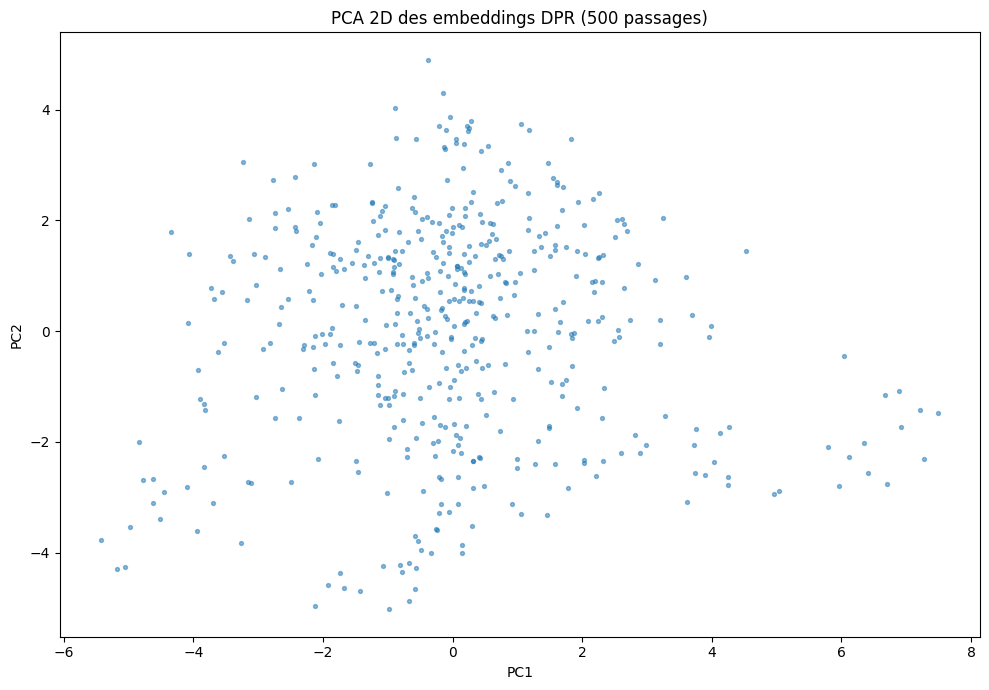

Variance expliquée : PC1=3.31%, PC2=2.93%


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from src.database.connection import get_connection

SAMPLE_SIZE = 500   # Passages to view

conn = get_connection()
cursor = conn.cursor()
cursor.execute(
    "SELECT passage_id, embedding FROM dpr ORDER BY passage_id LIMIT %s",
    (SAMPLE_SIZE,)
)
rows = cursor.fetchall()
cursor.close()
conn.close()

pids = [r[0] for r in rows]
# pgvector returns embeddings as strings "[0.1,0.2,...]"
embs = np.array([list(map(float, r[1].strip("[]").split(","))) for r in rows])

pca = PCA(n_components=2)
coords = pca.fit_transform(embs)

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], s=8, alpha=0.5)
plt.title(f"PCA 2D des embeddings DPR ({SAMPLE_SIZE} passages)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()
print(f"Variance expliquée : PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")